In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Settings
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


In [2]:
# Load data
df = pd.read_csv('customer_data.csv')
print(f'Dataset shape: {df.shape}')

# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

print(f'Missing values after cleaning: {df.isnull().sum().sum()}')
df.head()

Dataset shape: (7043, 21)
Missing values after cleaning: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# List of columns to encode
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
                    'MultipleLines', 'InternetService', 'OnlineSecurity',
                    'OnlineBackup', 'DeviceProtection', 'TechSupport',
                    'StreamingTV', 'StreamingMovies', 'Contract',
                    'PaperlessBilling', 'PaymentMethod']

# Create dummy variables
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Convert Churn to binary (Yes=1, No=0)
df_encoded['Churn'] = df_encoded['Churn'].map({'Yes': 1, 'No': 0})

print(f'Original columns: {df.shape[1]}')
print(f'After encoding: {df_encoded.shape[1]}')
print(f'\nChurn distribution:')
print(df_encoded['Churn'].value_counts())

Original columns: 21
After encoding: 32

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [4]:
# Drop non-predictive columns
df_model = df_encoded.drop(['customerID'], axis=1)

# Separate features (X) and target (y)
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTraining set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')

Features shape: (7043, 30)
Target shape: (7043,)

Training set: 5634 samples
Test set: 1409 samples


Logistic Regression Accuracy: 0.8048

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



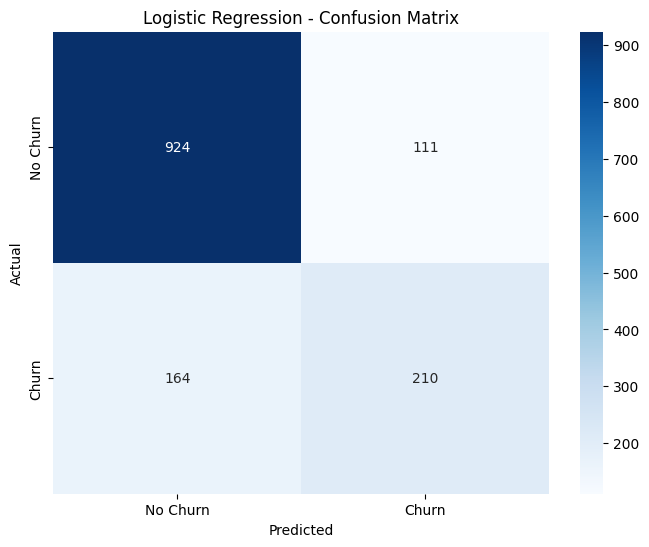

In [8]:
# Fix: convert all boolean columns to integers
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Create and train the model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

# Calculate accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f'Logistic Regression Accuracy: {lr_accuracy:.4f}')

# Detailed report
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr))

# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

In [7]:
# Check where NaN values are
print("NaN values in X_train:", X_train.isna().sum().sum())
print("NaN values in X_test:", X_test.isna().sum().sum())

# Fill all remaining NaN values with 0
X_train = X_train.fillna(0).astype(float)
X_test = X_test.fillna(0).astype(float)

print("After fix:")
print("NaN values in X_train:", X_train.isna().sum().sum())
print("NaN values in X_test:", X_test.isna().sum().sum())
print("All good! ✅")

NaN values in X_train: 8
NaN values in X_test: 3
After fix:
NaN values in X_train: 0
NaN values in X_test: 0
All good! ✅


Decision Tree Accuracy: 0.7942

Top 10 Most Important Features:
                                feature  importance
1                                tenure    0.422047
10          InternetService_Fiber optic    0.358061
3                          TotalCharges    0.037156
28       PaymentMethod_Electronic check    0.036814
2                        MonthlyCharges    0.025461
9                     MultipleLines_Yes    0.023665
12   OnlineSecurity_No internet service    0.020699
25                    Contract_Two year    0.019628
22  StreamingMovies_No internet service    0.017404
19                      TechSupport_Yes    0.013007


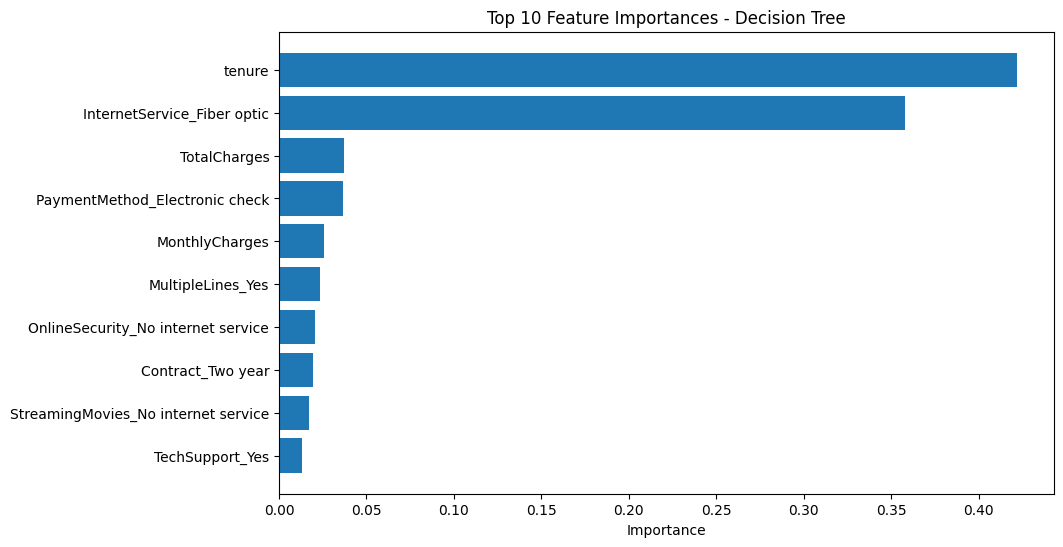

In [9]:
# Create and train decision tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)

# Calculate accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f'Decision Tree Accuracy: {dt_accuracy:.4f}')

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

print('\nTop 10 Most Important Features:')
print(feature_importance.head(10))

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'].head(10),
         feature_importance['importance'].head(10))
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances - Decision Tree')
plt.gca().invert_yaxis()
plt.show()

Random Forest Accuracy: 0.8062

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



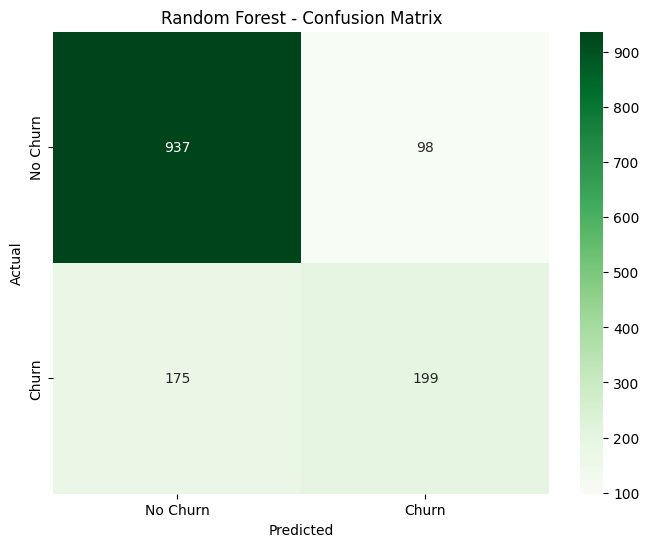

In [10]:
# Create and train random forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10
)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Calculate accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {rf_accuracy:.4f}')

# Classification report
print('\nRandom Forest Classification Report:')
print(classification_report(y_test, y_pred_rf))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest - Confusion Matrix')
plt.show()

Model Comparison:
                 Model  Accuracy
2        Random Forest  0.806246
0  Logistic Regression  0.804826
1        Decision Tree  0.794180

🏆 Best Model: Random Forest with 0.8062 accuracy


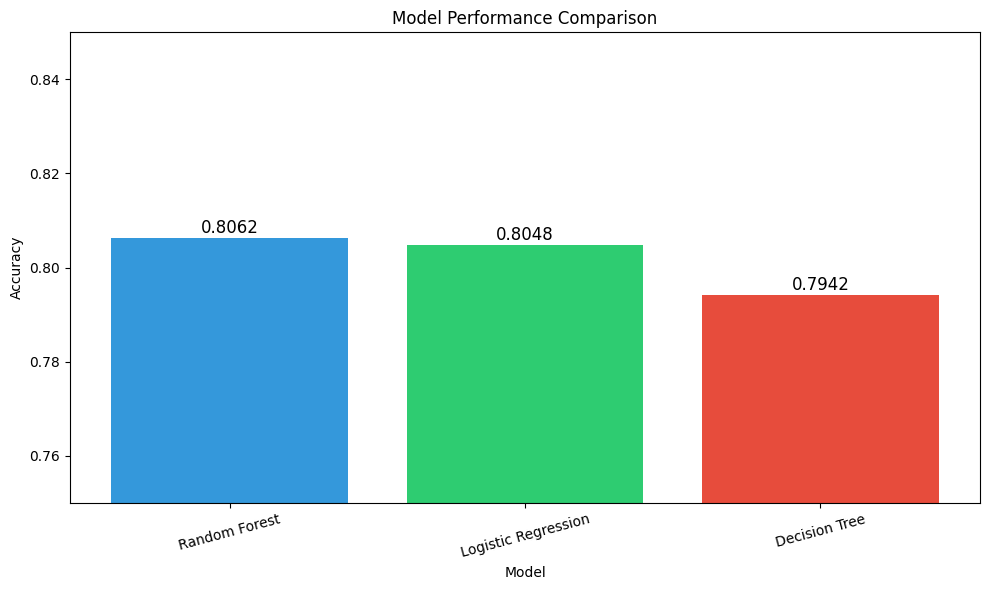

In [11]:
# Create comparison table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [lr_accuracy, dt_accuracy, rf_accuracy]
})

results = results.sort_values('Accuracy', ascending=False)
print('Model Comparison:')
print(results)

best_model = results.iloc[0]['Model']
best_accuracy = results.iloc[0]['Accuracy']
print(f'\n🏆 Best Model: {best_model} with {best_accuracy:.4f} accuracy')

# Visualization
plt.figure(figsize=(10, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c']
bars = plt.bar(results['Model'], results['Accuracy'], color=colors)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.ylim(0.75, 0.85)
plt.xticks(rotation=15)

# Add value labels on bars
for bar, val in zip(bars, results['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

In [12]:
print("=" * 50)
print("LAB 2 SUMMARY")
print("=" * 50)
print(f"\n🥇 Best Model: Random Forest (80.62%)")
print(f"🥈 Logistic Regression: 80.48%")
print(f"🥉 Decision Tree: 79.42%")
print("\nTop Predictive Features:")
print("1. Tenure")
print("2. InternetService - Fiber Optic")
print("3. TotalCharges")
print("4. PaymentMethod - Electronic Check")
print("5. MonthlyCharges")
print("\nNext Steps:")
print("- Week 3: Hyperparameter tuning to reach 85%+")
print("- Try XGBoost for better performance")

LAB 2 SUMMARY

🥇 Best Model: Random Forest (80.62%)
🥈 Logistic Regression: 80.48%
🥉 Decision Tree: 79.42%

Top Predictive Features:
1. Tenure
2. InternetService - Fiber Optic
3. TotalCharges
4. PaymentMethod - Electronic Check
5. MonthlyCharges

Next Steps:
- Week 3: Hyperparameter tuning to reach 85%+
- Try XGBoost for better performance
